# **CAPSTONE PROJECT(FRAUD DETECTION)**

In [1]:
import pandas as pd
df = pd.read_csv('/content/transactions_fraud.csv')
df.head(10)

,transaction_id,customer_id,device_id,merchant_id,timestamp,amount,payment_method,is_international,merchant_category,ip_address_risk_score,...,location_change_flag,authentication_method,otp_success_rate_customer,past_fraud_count_customer,past_disputes_customer,merchant_historical_fraud_rate,hour_of_day,day_of_week,is_weekend,is_fraud
0,1,1357,20937,720,1/18/24 19:23,18780.52,WALLET,0,Travel,0.243550,...,0,NONE,0.769328,1,2,0.069502,19,3,0,0
1,2,4095,29542,764,3/30/24 2:22,18955.06,CARD,0,Electronics,0.119761,...,1,OTP,0.468411,1,1,0.010010,2,5,1,0
2,3,3618,25236,671,1/4/24 17:26,10743.34,UPI,0,Fashion,0.565367,...,0,PIN,0.464356,0,1,0.118434,17,3,0,0
3,4,2755,29904,624,1/27/24 16:00,5054.75,CARD,0,Utilities,0.843842,...,0,PIN,0.635799,0,3,0.114947,16,5,1,0
4,5,2732,24151,501,2/20/24 23:14,14799.50,CARD,0,Gaming,0.202402,...,0,OTP,0.684301,2,0,0.014550,23,1,0,0
5,6,4434,28331,683,3/23/24 0:51,13248.40,UPI,0,Fashion,0.823163,...,0,OTP,0.873178,1,1,0.027156,0,5,1,0
6,7,1343,23308,772,3/7/24 2:15,17512.72,UPI,0,Grocery,0.532912,...,1,OTP,0.466269,2,2,0.031229,2,3,0,0
7,8,3789,24438,542,3/21/24 21:21,17049.18,UPI,0,Fashion,0.191345,...,0,OTP,0.579594,2,0,0.091981,21,3,0,0
8,9,1805,23468,573,2/9/24 19:25,5603.14,UPI,0,Fashion,0.232124,...,0,PIN,0.684170,2,0,0.079696,19,4,0,0
9,10,1376,25474,658,3/17/24 22:55,11700.76,UPI,0,Gaming,0.344732,...,0,OTP,0.891375,1,4,0.084364,22,6,1,0


In [2]:
df.info()

df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   transaction_id                  50000 non-null  int64  
 1   customer_id                     50000 non-null  int64  
 2   device_id                       50000 non-null  int64  
 3   merchant_id                     50000 non-null  int64  
 4   timestamp                       50000 non-null  object 
 5   amount                          50000 non-null  float64
 6   payment_method                  50000 non-null  object 
 7   is_international                50000 non-null  int64  
 8   merchant_category               50000 non-null  object 
 9   ip_address_risk_score           50000 non-null  float64
 10  device_trust_score              50000 non-null  float64
 11  txn_count_last_24h              50000 non-null  int64  
 12  avg_amount_last_24h             

(50000, 25)

In [3]:
df.describe()

,transaction_id,customer_id,device_id,merchant_id,amount,is_international,ip_address_risk_score,device_trust_score,txn_count_last_24h,avg_amount_last_24h,...,device_change_flag,location_change_flag,otp_success_rate_customer,past_fraud_count_customer,past_disputes_customer,merchant_historical_fraud_rate,hour_of_day,day_of_week,is_weekend,is_fraud
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,2997.254240,25002.291480,650.02924,10015.213203,0.029580,0.499724,0.498710,5.495940,7534.791518,...,0.079780,0.098740,0.700258,0.99622,1.993440,0.075142,11.531080,2.960880,0.274120,0.100560
std,14433.901067,1155.746991,2883.264316,86.47709,5756.852793,0.169427,0.287707,0.289137,3.441735,4296.720184,...,0.270955,0.298316,0.172999,0.81730,1.409538,0.043377,6.906101,1.975284,0.446074,0.300748
min,1.000000,1000.000000,20000.000000,500.00000,50.510000,0.000000,0.000026,0.000004,0.000000,100.040000,...,0.000000,0.000000,0.400004,0.00000,0.000000,0.000008,0.000000,0.000000,0.000000,0.000000
25%,12500.750000,1994.000000,22513.000000,575.00000,5007.712500,0.000000,0.250929,0.247243,3.000000,3828.462500,...,0.000000,0.000000,0.550023,0.00000,1.000000,0.037392,6.000000,1.000000,0.000000,0.000000
50%,25000.500000,3002.000000,25010.500000,650.00000,9971.515000,0.000000,0.498304,0.499904,6.000000,7504.350000,...,0.000000,0.000000,0.699992,1.00000,2.000000,0.075251,12.000000,3.000000,0.000000,0.000000
75%,37500.250000,3996.000000,27496.000000,725.00000,15017.282500,0.000000,0.749212,0.747916,8.000000,11266.432500,...,0.000000,0.000000,0.850747,2.00000,3.000000,0.112882,18.000000,5.000000,1.000000,0.000000
max,50000.000000,4999.000000,29999.000000,799.00000,19999.080000,1.000000,0.999984,0.999948,11.000000,14999.890000,...,1.000000,1.000000,0.999985,2.00000,4.000000,0.149995,23.000000,6.000000,1.000000,1.000000


In [4]:
# checking imbalance data
df['is_fraud'].value_counts()

,count
is_fraud,
0,44972
1,5028


In [5]:
# checking missing values
df.isnull().sum().sort_values()


,0
transaction_id,0
customer_id,0
device_id,0
merchant_id,0
timestamp,0
amount,0
payment_method,0
is_international,0
merchant_category,0
ip_address_risk_score,0


In [6]:
# checking duplicate values
df.duplicated().sum()


np.int64(0)

In [7]:
# now checking features which are object datatype. If yes, then encode them.
df.dtypes


,0
transaction_id,int64
customer_id,int64
device_id,int64
merchant_id,int64
timestamp,object
amount,float64
payment_method,object
is_international,int64
merchant_category,object
ip_address_risk_score,float64


In [8]:
# Separating Feature & Target variable
x = df.drop('is_fraud', axis=1)
y = df['is_fraud']

x,y

(       transaction_id  customer_id  device_id  merchant_id      timestamp  \
 0                   1         1357      20937          720  1/18/24 19:23   
 1                   2         4095      29542          764   3/30/24 2:22   
 2                   3         3618      25236          671   1/4/24 17:26   
 3                   4         2755      29904          624  1/27/24 16:00   
 4                   5         2732      24151          501  2/20/24 23:14   
 ...               ...          ...        ...          ...            ...   
 49995           49996         3219      29854          601   2/20/24 9:37   
 49996           49997         4958      20174          522  1/31/24 21:26   
 49997           49998         1642      25744          587  1/11/24 21:25   
 49998           49999         2240      20052          680   3/22/24 7:47   
 49999           50000         3559      29372          592  3/24/24 18:35   
 
          amount payment_method  is_international merchant_cat

In [9]:
df['is_fraud'].value_counts(normalize=True) * 100


,proportion
is_fraud,
0,89.944
1,10.056


In [10]:
# splitting test and train
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
   x, y,
    test_size=0.3,
    random_state=45,
    stratify=y
)


In [11]:
print(x_test)

       transaction_id  customer_id  device_id  merchant_id      timestamp  \
34244           34245         1892      20128          588    1/4/24 2:23   
10807           10808         1586      27139          737  2/20/24 13:03   
3632             3633         1148      24461          681   3/1/24 18:58   
23556           23557         3876      21485          644   1/1/24 16:59   
22822           22823         1794      27943          560  3/23/24 13:22   
...               ...          ...        ...          ...            ...   
21548           21549         3911      23642          767  1/29/24 18:21   
35168           35169         2736      22204          536  1/20/24 20:53   
35819           35820         4703      24738          503  3/17/24 23:06   
31797           31798         1209      20889          760  1/18/24 16:35   
39606           39607         4701      26521          559  1/11/24 17:14   

         amount payment_method  is_international merchant_category  \
34244

In [12]:
print(x_train)

       transaction_id  customer_id  device_id  merchant_id      timestamp  \
26655           26656         2019      20622          653  1/24/24 18:45   
19051           19052         3295      23785          532  1/10/24 23:39   
14691           14692         3147      23070          663   2/23/24 9:04   
18295           18296         2806      28890          625  1/28/24 18:03   
29204           29205         2435      24638          540  1/20/24 18:33   
...               ...          ...        ...          ...            ...   
23390           23391         3090      21373          596   1/2/24 19:22   
6546             6547         3760      29577          620   1/6/24 15:01   
37463           37464         1441      29700          648   1/21/24 5:15   
6635             6636         1407      25404          729   3/3/24 22:07   
19549           19550         4110      29082          598    3/5/24 1:37   

         amount payment_method  is_international merchant_category  \
26655

In [13]:
print(y_test)

34244    0
10807    0
3632     0
23556    0
22822    0
        ..
21548    0
35168    0
35819    0
31797    0
39606    0
Name: is_fraud, Length: 15000, dtype: int64


In [14]:
# identify Categorical Columns
cat_cols = x.select_dtypes(include='object').columns
cat_cols

Index(['timestamp', 'payment_method', 'merchant_category',
       'authentication_method'],
      dtype='object')

In [15]:
# encoding categorical columns
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)

preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('cat',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore'),
                                 Index(['timestamp', 'payment_method', 'merchant_category',
       'authentication_method'],
      dtype='object'))])

# **BY LOGISTIC REGRESSION**

In [16]:
# creating pipeline to maintain consistency in preprocessing
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000))
])

model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  Index(['timestamp', 'payment_method', 'merchant_category',
       'authentication_method'],
      dtype='object'))])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [17]:
model.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppr

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  Index(['timestamp', 'payment_method', 'merchant_category',
       'authentication_method'],
      dtype='object'))])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [18]:
# Now making prediction
y_pred = model.predict(x_test)
y_pred


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


array([0, 0, 1, ..., 0, 0, 0])

In [19]:
# now checking accuracy, f1 score, recall, precision
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))



Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.79      0.86     13492
           1       0.22      0.51      0.30      1508

    accuracy                           0.77     15000
   macro avg       0.58      0.65      0.58     15000
weighted avg       0.86      0.77      0.80     15000

Accuracy: 0.765

Confusion Matrix:

[[10711  2781]
 [  744   764]]


In logistic regression, model has correctly identified 752 and missed 756 out of 1508 fraud transactions, giving a recall of 50%. This indicates moderate fraud detection capability but needs more improvement.

# **BY RANDOM FOREST**

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# Create model with Pipeline to include preprocessing
randf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=50,
    ))
])

# Fit FIRST
randf_model.fit(x_train, y_train)

# Get probability for fraud class (class 1)
y_prob_randf_model = randf_model.predict_proba(x_test)[:, 1]

# Apply threshold
y_pred_randf_model = (y_prob_randf_model > 0.18).astype(int)

y_pred_randf_model

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


array([0, 0, 0, ..., 0, 0, 0])

In [21]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_randf_model))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_randf_model))

              precision    recall  f1-score   support

           0       0.91      0.95      0.93     13492
           1       0.29      0.18      0.22      1508

    accuracy                           0.87     15000
   macro avg       0.60      0.56      0.58     15000
weighted avg       0.85      0.87      0.86     15000


Confusion Matrix:

[[12839   653]
 [ 1241   267]]


The Random Forest model achieved an accuracy of 87% on the test dataset. However, the recall for fraudulent transactions was only 18%, indicating that the model struggled to correctly identify fraud cases due to class imbalance in the dataset.

## **BY XGBOOST**

In [22]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix # Added for evaluation

# Calculate imbalance ratio
neg = y_train.value_counts()[0]
pos = y_train.value_counts()[1]
scale_pos_weight = neg / pos

# Create model pipeline
xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.06,
        scale_pos_weight=scale_pos_weight,
        random_state=50,
        eval_metric='logloss'
    ))
])

# Train the pipeline
xgb_model.fit(x_train, y_train)

# Predict probabilities
y_prob_xgb = xgb_model.predict_proba(x_test)[:,1]

# Apply threshold (start with 0.4)
y_pred_xgb = (y_prob_xgb > 0.25).astype(int)

# Evaluate
print(classification_report(y_test, y_pred_xgb))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


              precision    recall  f1-score   support

           0       0.97      0.17      0.29     13492
           1       0.11      0.96      0.20      1508

    accuracy                           0.25     15000
   macro avg       0.54      0.56      0.25     15000
weighted avg       0.89      0.25      0.28     15000


Confusion Matrix:

[[ 2273 11219]
 [   65  1443]]


The XGBoost model demonstrated strong performance in handling the class imbalance present in the fraud detection dataset. By using the scale_pos_weight parameter, the model was able to give higher importance to the minority fraud class during training.
Due to its better recall for the fraud class and overall balanced performance, XGBoost was selected as the final model.

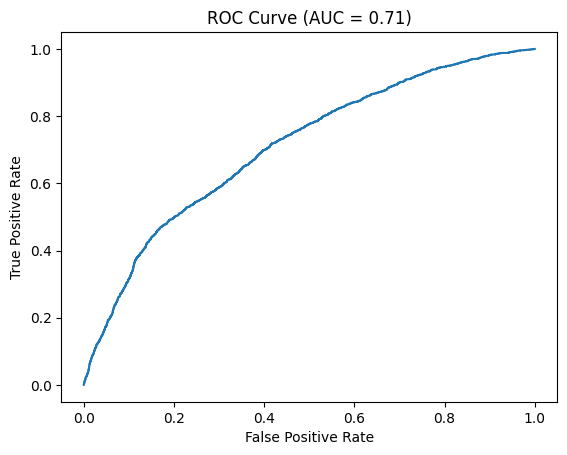

ROC AUC: 0.7088255118860101


In [23]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgb)
roc_auc = roc_auc_score(y_test, y_prob_xgb)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {roc_auc:.2f})")
plt.show()

print("ROC AUC:", roc_auc)


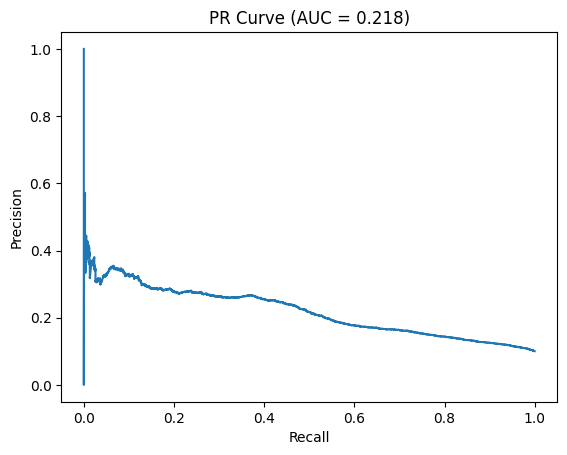

PR AUC: 0.21800106736492852


In [24]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_prob_xgb)
pr_auc = auc(recall, precision)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"PR Curve (AUC = {pr_auc:.3f})")
plt.show()

print("PR AUC:", pr_auc)
